In [1]:
import numpy as np # بتتعامل مع الأرقام
import cv2 # بتتعامل مع. معالجه الصور علشان تخلي الصور فهومه لل AI
import matplotlib.pyplot as plt # هي مكتبه لعرض الرسوم و البيانات
from skimage.feature import hog #ال hog بيعمل
from tensorflow.keras.models import Sequential, Model #علشان نقدر نعمل موديل
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist

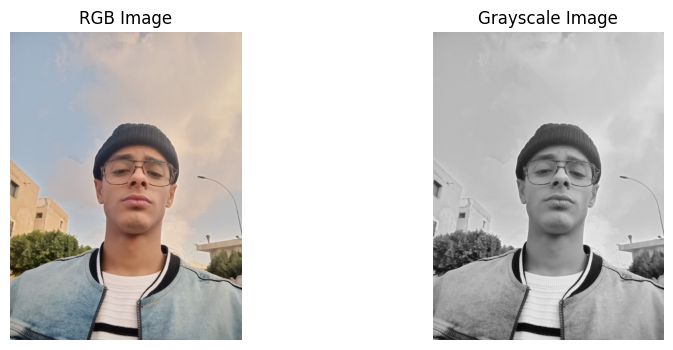

In [13]:
# Load an image from file

image = cv2.imread('/content/nnn.jpeg')  # Replace with your image file name
# Convert from RGB (OpenCV default) to RGB for display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert to Grayscale
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Display both versions
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("RGB Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(image_gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

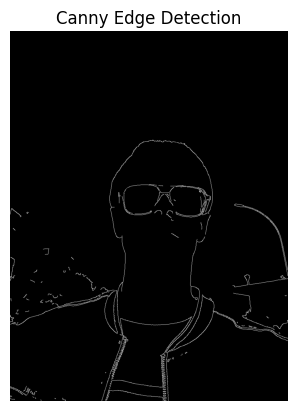

In [32]:
# Apply Canny edge detection
edges = cv2.Canny(image_gray, threshold1=300, threshold2=180)

# Display the edges
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")
plt.show()

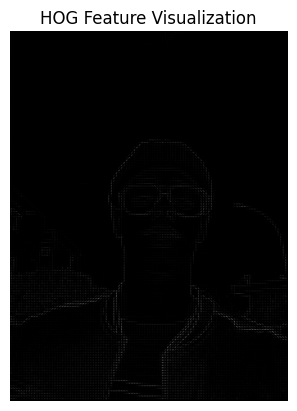

In [33]:
# Extract HOG features and visualize them
hog_features, hog_image = hog(image_gray, visualize=True)

# Display the HOG image
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Feature Visualization")
plt.axis("off")
plt.show()

In [34]:
# Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape to include channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes for digits 0–9
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [36]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))



Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.8948 - loss: 0.3618 - val_accuracy: 0.9823 - val_loss: 0.0582
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.9815 - loss: 0.0605 - val_accuracy: 0.9850 - val_loss: 0.0425
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.9878 - loss: 0.0405 - val_accuracy: 0.9877 - val_loss: 0.0386
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 18ms/step - accuracy: 0.9907 - loss: 0.0296 - val_accuracy: 0.9891 - val_loss: 0.0332
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9927 - loss: 0.0234 - val_accuracy: 0.9877 - val_loss: 0.0368


In [37]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"VAL Accuracy: {test_accuracy:.2f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9831 - loss: 0.0499
VAL Accuracy: 0.99


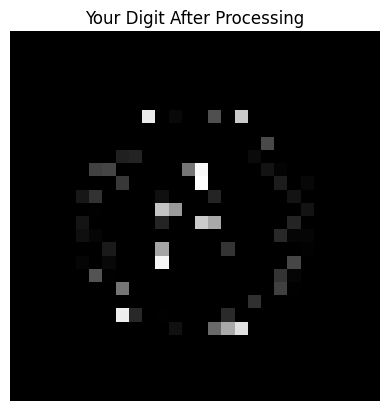

In [38]:
# Load the image in grayscale
img = cv2.imread('/content/NANA.jpeg', cv2.IMREAD_GRAYSCALE)

# Resize to 28x28 (same as MNIST)
img_resized = cv2.resize(img, (28, 28))

# Invert if background is dark
if np.mean(img_resized) > 127:
    img_resized = 255 - img_resized

# Normalize and reshape
img_ready = img_resized / 255.0
img_ready = img_ready.reshape(1, 28, 28, 1)

# Display processed image
plt.imshow(img_resized, cmap='gray')
plt.title("Your Digit After Processing")
plt.axis('off')
plt.show()